# Phase 1: Data Understanding & EDA
This notebook performs exploratory data analysis on the KKBox Churn Prediction dataset.
**Note on Data Versions:** Both v1 and v2 versions of `train` and `transactions` data were found in `data/raw/`. As per project conventions, we default to using the **v2** datasets, as they represent the most complete and updated snapshot provided by KKBox.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import py7zr

# Define all file paths
DATA_DIR = '../data/raw'
MEMBERS_PATH = os.path.join(DATA_DIR, 'members_v3.csv')
TRAIN_PATH = os.path.join(DATA_DIR, 'train_v2.csv')
TRANSACTIONS_PATH = os.path.join(DATA_DIR, 'transactions_v2.csv')
USER_LOGS_PATH = os.path.join(DATA_DIR, 'user_logs.csv')

# Verify required files exist
expected_files = [MEMBERS_PATH, TRAIN_PATH, TRANSACTIONS_PATH, USER_LOGS_PATH]
missing = [f for f in expected_files if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Missing required data files: {missing}. Please ensure data is present in data/raw/")
else:
    print("All required data files located successfully.")

# Helper to read 7z if needed, though pandas can read 7z natively if py7zr is installed
# e.g., pd.read_csv('file.7z')

All required data files located successfully.


## 2. Load and inspect tables
Loading datasets and inspecting their shapes, datatypes, and initial rows. Printing memory usage.

In [2]:
# 1. Members
df_members = pd.read_csv(MEMBERS_PATH)
print("--- members_v3 ---")
print("Shape:", df_members.shape)
print("Memory Usage (MB):", df_members.memory_usage(deep=True).sum() / 1e6)
print(df_members.dtypes)
display(df_members.head())
display(df_members.describe())

--- members_v3 ---
Shape: (6769473, 6)
Memory Usage (MB): 635.286931
msno                        str
city                      int64
bd                        int64
gender                      str
registered_via            int64
registration_init_time    int64
dtype: object


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


,city,bd,registered_via,registration_init_time
count,6.769473e+06,6.769473e+06,6.769473e+06,6.769473e+06
mean,3.847358e+00,9.795794e+00,5.253069e+00,2.014518e+07
std,5.478359e+00,1.792590e+01,2.361398e+00,2.318601e+04
min,1.000000e+00,-7.168000e+03,-1.000000e+00,2.004033e+07
25%,1.000000e+00,0.000000e+00,4.000000e+00,2.014042e+07
50%,1.000000e+00,0.000000e+00,4.000000e+00,2.015101e+07
75%,4.000000e+00,2.100000e+01,7.000000e+00,2.016060e+07
max,2.200000e+01,2.016000e+03,1.900000e+01,2.017043e+07


In [3]:
# 2. Train (v2)
df_train = pd.read_csv(TRAIN_PATH)
print("\n--- train_v2 ---")
print("Shape:", df_train.shape)
print("Memory Usage (MB):", df_train.memory_usage(deep=True).sum() / 1e6)
display(df_train.head())


--- train_v2 ---
Shape: (970960, 2)
Memory Usage (MB): 58.257732


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [4]:
# 3. Transactions (v2)
# File is ~50MB compressed, can be loaded into memory for EDA
df_trans = pd.read_csv(TRANSACTIONS_PATH)
print("\n--- transactions_v2 ---")
print("Shape:", df_trans.shape)
print("Memory Usage (MB):", df_trans.memory_usage(deep=True).sum() / 1e6)
print(df_trans.dtypes)
display(df_trans.head())


--- transactions_v2 ---
Shape: (1431009, 9)
Memory Usage (MB): 165.997131
msno                        str
payment_method_id         int64
payment_plan_days         int64
plan_list_price           int64
actual_amount_paid        int64
is_auto_renew             int64
transaction_date          int64
membership_expire_date    int64
is_cancel                 int64
dtype: object


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0


### User Logs
We perform a small sample load (nrows=5000) for visual inspection, followed by a **size-agnostic aggregation using DuckDB** which will work seamlessly when the real 30GB+ file is used.
**Synthetic Data Notice**: `user_logs.csv` is currently a synthetic ~113k row sample representing ~8,000 customers. Findings below are illustrative of the generation script's logic.

In [5]:
# 4a. User logs - Sample only load for inspection
df_logs_sample = pd.read_csv(USER_LOGS_PATH, nrows=5000)
print("--- user_logs (nrows=5000) ---")
display(df_logs_sample.head())

--- user_logs (nrows=5000) ---


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,Pa1Umj2p0UaU9HcRHTXkC3JqQU8GQmc2IsQI/SIWsao=,20171101,10,2,3,0,10,23,4704.0
1,Pa1Umj2p0UaU9HcRHTXkC3JqQU8GQmc2IsQI/SIWsao=,20171102,10,1,2,0,19,26,7327.0
2,Pa1Umj2p0UaU9HcRHTXkC3JqQU8GQmc2IsQI/SIWsao=,20171103,10,2,3,0,9,18,3979.0
3,Pa1Umj2p0UaU9HcRHTXkC3JqQU8GQmc2IsQI/SIWsao=,20171104,8,3,4,0,12,14,4991.0
4,Pa1Umj2p0UaU9HcRHTXkC3JqQU8GQmc2IsQI/SIWsao=,20171105,8,3,1,0,14,9,4667.0


In [6]:
# 4b. User logs - Size-agnostic aggregation pass via DuckDB
# This SQL logic will scale to the 30GB+ file without running out of memory.
con = duckdb.connect()
query = f"""
SELECT 
    msno,
    COUNT(*) as total_log_days,
    SUM(num_25) as total_num_25,
    SUM(num_100) as total_num_100,
    AVG(total_secs) as avg_daily_secs
FROM read_csv_auto('{USER_LOGS_PATH}')
GROUP BY msno
LIMIT 5
"""
df_logs_agg = con.execute(query).df()
print("--- user_logs (DuckDB Aggregation) ---")
display(df_logs_agg)

--- user_logs (DuckDB Aggregation) ---


,msno,total_log_days,total_num_25,total_num_100,avg_daily_secs
0,Q2n+UScfEq1uV1Qu2dcbtjNDRQ0KPPTNUW4CGBRnPtw=,77,498.0,731.0,4271.532468
1,9k6dpnq3YdDjpVODTQGlRHDQdepW87tORNV1okmkM1A=,147,369.0,388.0,1296.258503
2,mEFXt7U9jIiZx4FIHdtnqvJjtnI6a8PgBHooI5iFj6U=,73,353.0,530.0,3312.219178
3,JDc2K/yhimRgV93yfQTfyF+o7a2XLTlapNHQ6un7pq4=,47,394.0,590.0,5563.191489
4,kY3zjOCLl3/DenpI/d1PprRP0SiF/bpSDrqJzB3SIQo=,128,470.0,684.0,2411.851562


## 3. Churn label exploration & definition
Churn definition: A customer is considered churned (is_churn=1) if they do not renew within 30 days of their expiration date. We've documented the precise calculation mechanics in `CHURN_DEFINITION.md` based on `WSDMChurnLabeller.scala`.

In [7]:
# Check distribution in train_v2
churn_dist = df_train['is_churn'].value_counts(normalize=True) * 100
print("Churn Distribution (%):\n", churn_dist)

Churn Distribution (%):
 is_churn
0    91.005809
1     8.994191
Name: proportion, dtype: float64


## 4. Class Balance
Understanding the target imbalance ratio for modeling (scale_pos_weight).

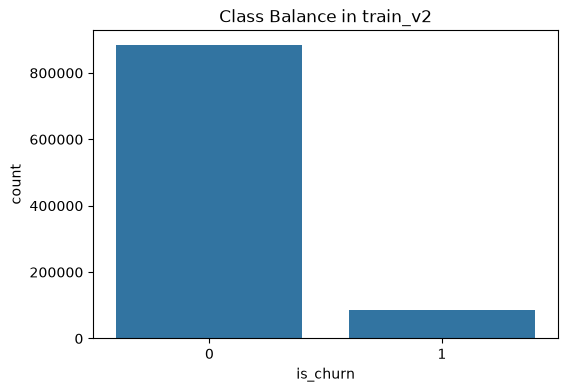

Imbalance Ratio (Negative/Positive): 10.12


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_train, x='is_churn')
plt.title("Class Balance in train_v2")
plt.show()

ratio = df_train['is_churn'].value_counts()[0] / df_train['is_churn'].value_counts()[1]
print(f"Imbalance Ratio (Negative/Positive): {ratio:.2f}")

## 5. Missingness Analysis

**Notes on User Logs**: Missingness in the synthetic user_logs reflects the generation script. Re-run this cell when real data is available.

| Table | Column | Null % | Notable Issue |
|---|---|---|---|
| members_v3 | gender | High | Gender is often not provided |
| members_v3 | bd | Low | Contains implausible ages (e.g. < 0, > 100) |
| transactions | various | Low/None | Check for duplicate daily transactions per msno |


In [9]:
print("Members Null %:\n", df_members.isnull().mean() * 100)
print("\nTransactions Null %:\n", df_trans.isnull().mean() * 100)

# Check for duplicate transactions (same msno, same transaction_date)
dupes = df_trans.duplicated(subset=['msno', 'transaction_date']).sum()
print(f"\nDuplicate transaction rows (same msno, same date): {dupes}")

Members Null %:
 msno                       0.000000
city                       0.000000
bd                         0.000000
gender                    65.433528
registered_via             0.000000
registration_init_time     0.000000
dtype: float64

Transactions Null %:
 msno                      0.0
payment_method_id         0.0
payment_plan_days         0.0
plan_list_price           0.0
actual_amount_paid        0.0
is_auto_renew             0.0
transaction_date          0.0
membership_expire_date    0.0
is_cancel                 0.0
dtype: float64

Duplicate transaction rows (same msno, same date): 33292


## 6. Time Range / Temporal Structure

In [10]:
print("Transactions: min date:", df_trans['transaction_date'].min(), "max date:", df_trans['transaction_date'].max())
print("Members: min expire date:", df_trans['membership_expire_date'].min(), "max expire date:", df_trans['membership_expire_date'].max())

# Plot record count over time to check right-censoring pattern
df_trans['trans_date_parsed'] = pd.to_datetime(df_trans['transaction_date'], format='%Y%m%d', errors='coerce')
df_trans.set_index('trans_date_parsed').resample('M').size().plot(title='Transactions over time')
plt.show()

Transactions: min date: 20150101 max date: 20170331
Members: min expire date: 20160419 max expire date: 20361015


ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

## 7. Cross-table Consistency
Checking how many users in `train_v2` have records in the other tables. Note: `user_logs` currently only covers ~8,000 customers due to the synthetic sample limit.

In [ ]:
train_msno = set(df_train['msno'])
print(f"% in members: {len(train_msno.intersection(set(df_members['msno']))) / len(train_msno) * 100:.2f}%")
print(f"% in transactions: {len(train_msno.intersection(set(df_trans['msno']))) / len(train_msno) * 100:.2f}%")

# Query unique msno from user_logs via DuckDB
logs_msno_query = con.execute(f"SELECT DISTINCT msno FROM read_csv_auto('{USER_LOGS_PATH}')").df()['msno']
print(f"% in user_logs (synthetic 8k sample): {len(train_msno.intersection(set(logs_msno_query))) / len(train_msno) * 100:.2f}%")

## 8. Light Visual EDA

In [ ]:
# Merge members and train for city EDA
df_eda = df_train.merge(df_members, on='msno', how='left')

plt.figure(figsize=(10, 4))
sns.barplot(data=df_eda, x='city', y='is_churn')
plt.title("Churn Rate by City")
plt.show()

# Average daily listening trend (synthetic data illustrative pattern)
query_trend = f"""
SELECT 
    t.is_churn,
    AVG(l.total_secs) as avg_secs
FROM read_csv_auto('{USER_LOGS_PATH}') l
JOIN read_csv_auto('{TRAIN_PATH}') t ON l.msno = t.msno
GROUP BY t.is_churn
"""
trend_df = con.execute(query_trend).df()
plt.figure(figsize=(6, 4))
sns.barplot(data=trend_df, x='is_churn', y='avg_secs')
plt.title("Synthetic Data — Illustrative Pattern: Avg Daily Listening (Churn vs Retained)")
plt.show()

## 9. Data Quality Decisions Log
The findings from this notebook are summarized in `DATA_QUALITY_NOTES.md` at the project root, detailing missingness strategies, outlier handling (like implausible ages in `bd`), and synthetic data considerations for Phase 2 feature engineering.